In [1]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
outlier_handler = OutlierHandling()

### data loading

In [2]:
mydata = pd.read_csv(r'data\BankChurners.csv')

data exploration

In [3]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

dropping the last two columns

In [4]:
columns_list = mydata.columns.tolist()
print(columns_list)
df = mydata.drop(columns=columns_list[-2:])
df = df.drop(columns='CLIENTNUM')

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [5]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### we have many outliers in our data

<Axes: >

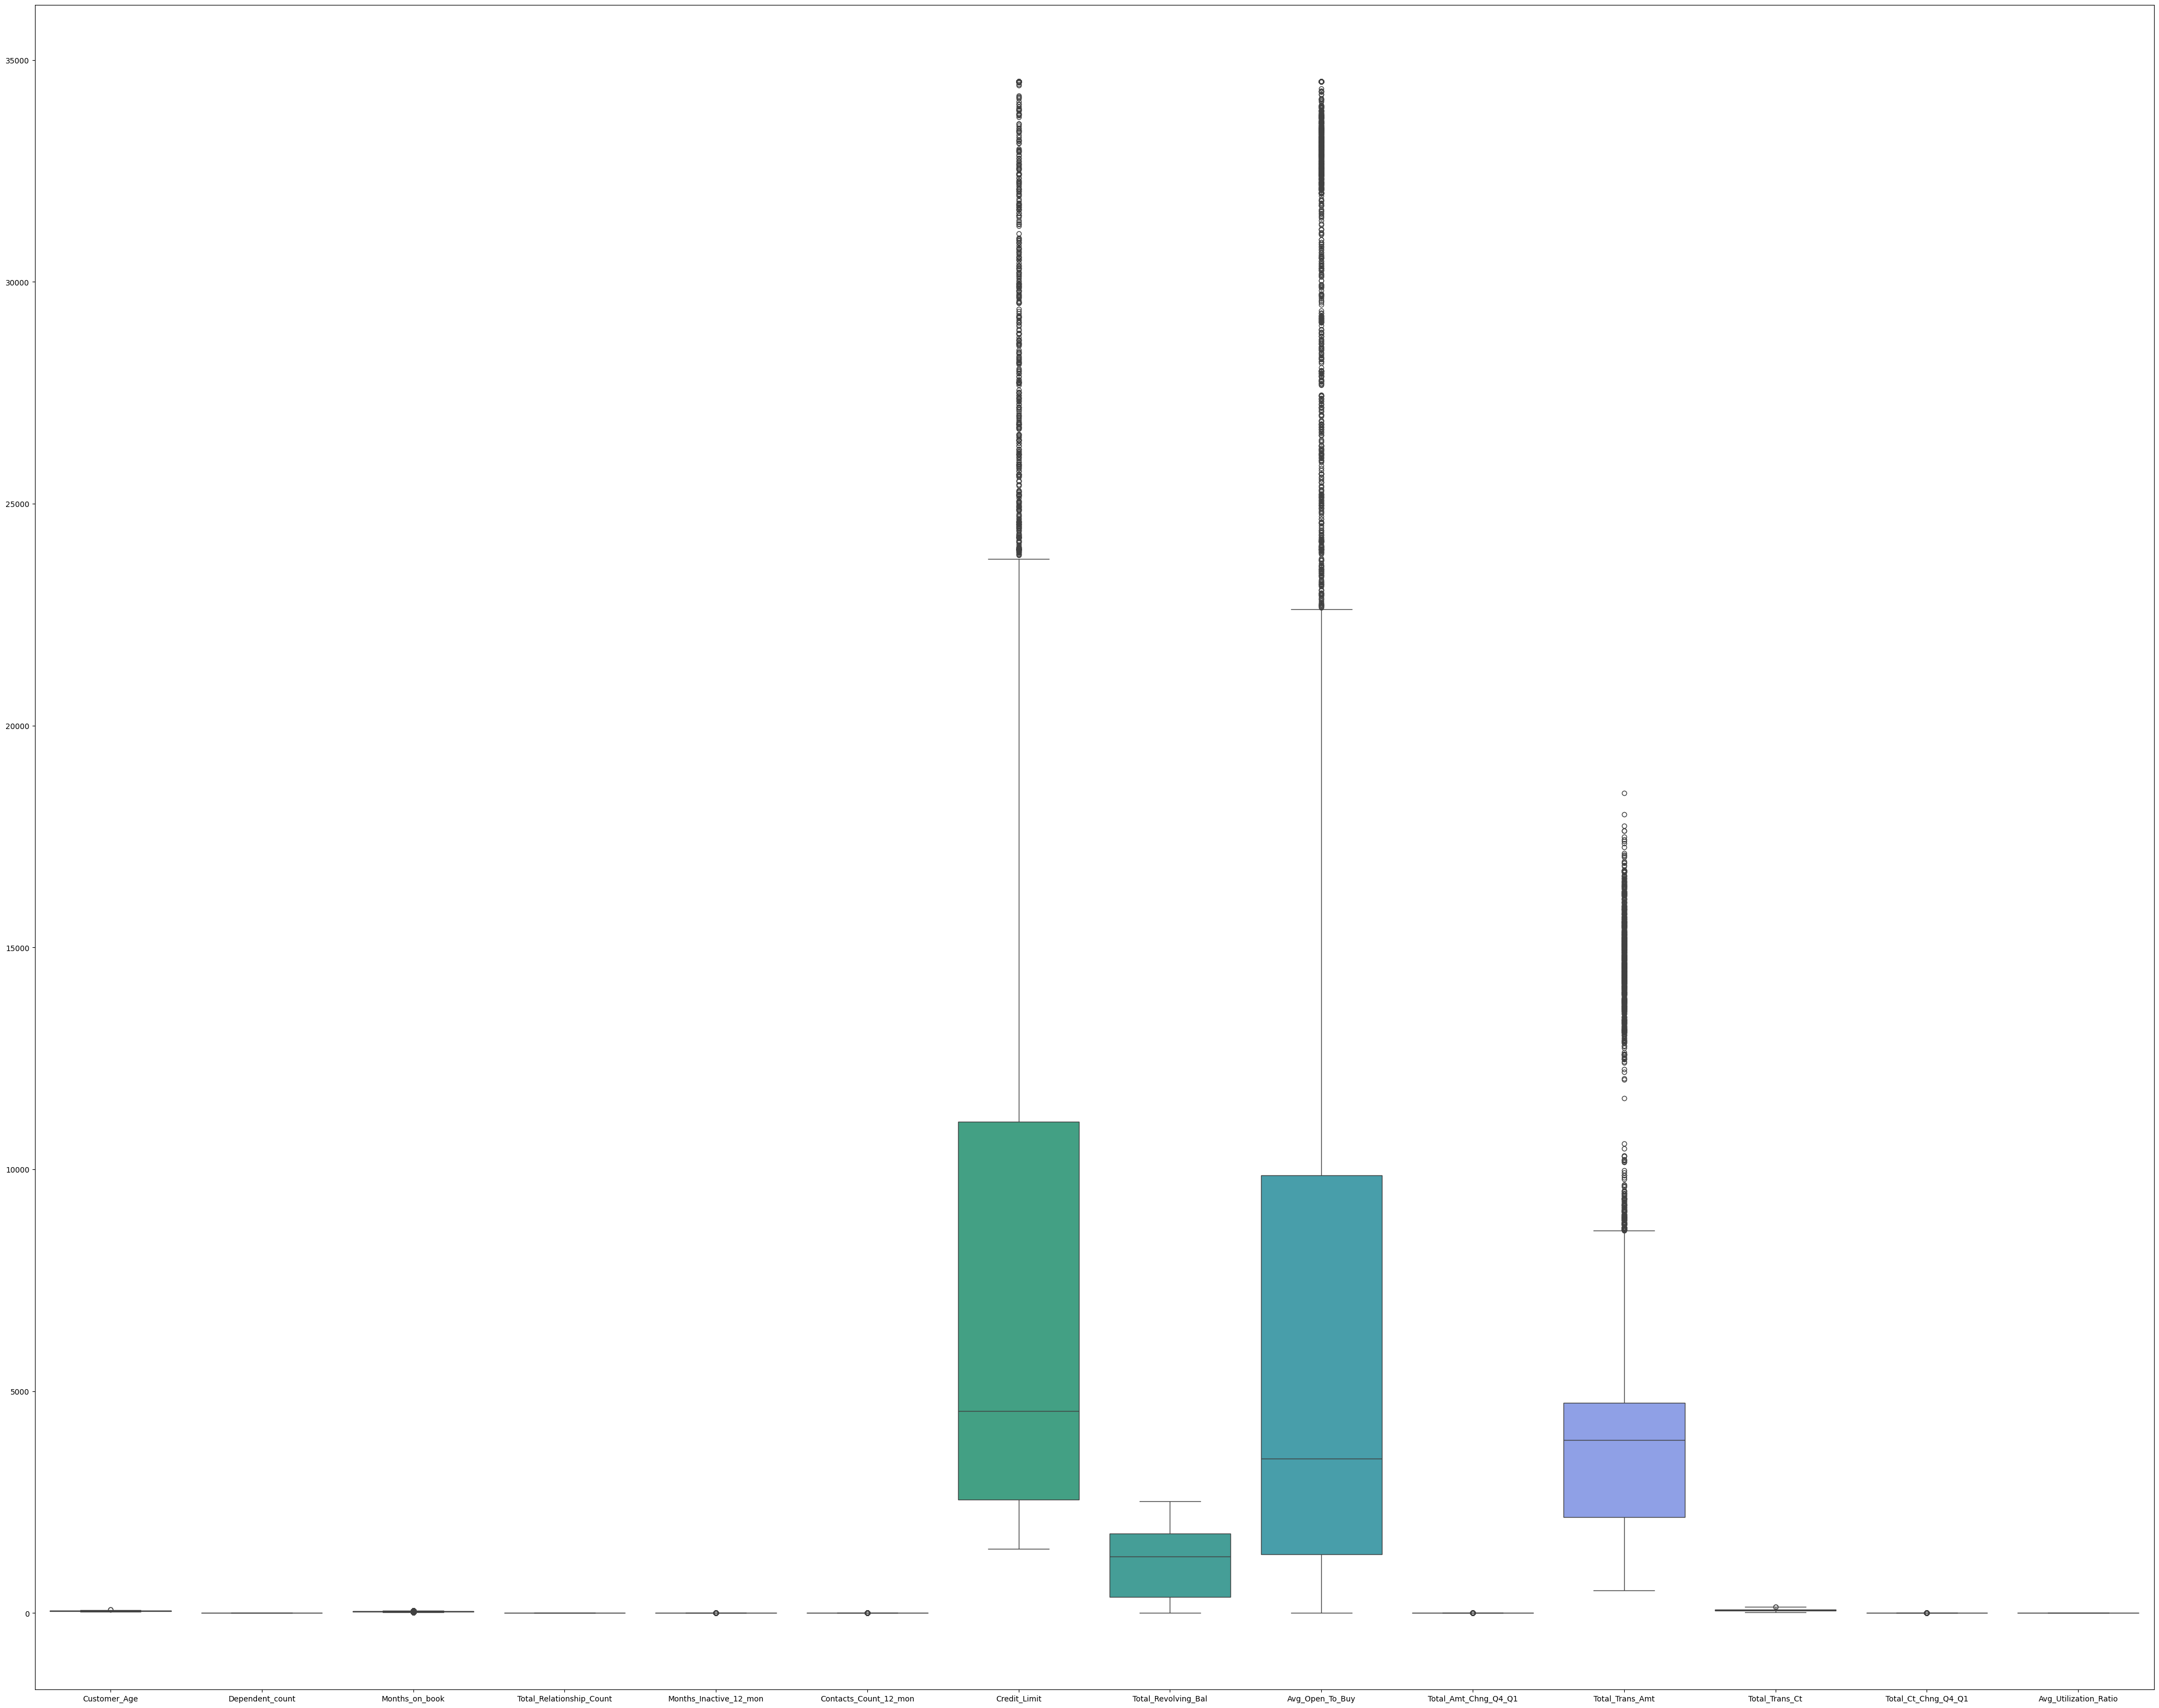

In [6]:
plt.figure(figsize=(50,40))
sns.boxplot(df)

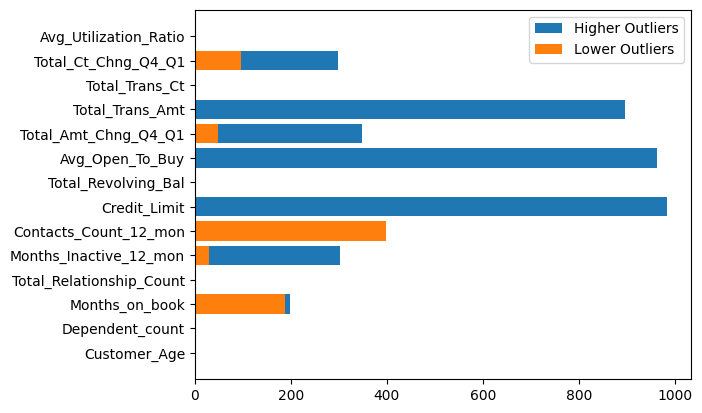

Customer_Age: 2, Customer_Age: 0, Total: 2
________________

Months_on_book: 198, Months_on_book: 188, Total: 386
________________

Months_Inactive_12_mon: 302, Months_Inactive_12_mon: 29, Total: 331
________________

Contacts_Count_12_mon: 230, Contacts_Count_12_mon: 399, Total: 629
________________

Credit_Limit: 984, Credit_Limit: 0, Total: 984
________________

Avg_Open_To_Buy: 963, Avg_Open_To_Buy: 0, Total: 963
________________

Total_Amt_Chng_Q4_Q1: 348, Total_Amt_Chng_Q4_Q1: 48, Total: 396
________________

Total_Trans_Amt: 896, Total_Trans_Amt: 0, Total: 896
________________

Total_Trans_Ct: 2, Total_Trans_Ct: 0, Total: 2
________________

Total_Ct_Chng_Q4_Q1: 298, Total_Ct_Chng_Q4_Q1: 96, Total: 394
________________



In [7]:
outlier_handler = OutlierHandling()

outlier_handler.plot(df)
outlier_handler.count_outliers_df(df)
# outlier_handler.display_outliers_df(df)


<Axes: ylabel='Credit_Limit'>

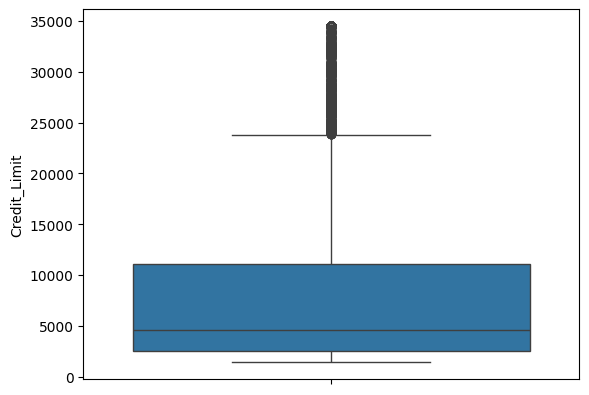

In [8]:
sns.boxplot(df["Credit_Limit"])